### Create Gaussian Process around dataset

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd

from agent.components.GaussianProcess import GASK
from agent.components.commons import ServiceType

s_type = ServiceType.QR
df = pd.read_csv("../statics/metrics_TSC_EXPLORE.csv")
# 2. Initialize and train
gp_service = GASK(s_type, show_figures=False)
gp_service.init_model(df, data_density=1.0)

INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-qr-detector - Target: max_tp
INFO:multiscale:train_gp_models took 302 ms to execute


### Gaussian Process gives you µ,s for an arbitrary point

In [2]:

%load_ext autoreload
%autoreload 2

# gp.predict(s_type, "max_tp", {'data_quality': 100, 'cores': 6.0})
# gp.predict(s_type, "max_tp", {'data_quality': 10000, 'cores': 600.0})
# gp.predict(s_type, "max_tp", {'data_quality': 100, 'cores': 6.0, 'model_size': 2.0})


from agent.components.commons import ServiceVar
from typing import Dict



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Test if the global optimizer converges to a nice result

In [3]:
from agent.components.GaussianProcess import get_empirical_variable_bounds
%load_ext autoreload
%autoreload 2

from agent.components.Optimizer import local_obj, solve_global
from agent.components.SLORegistry_v2 import SLO_Registry

slo_lib = SLO_Registry("../statics/config/service_level_objectives.yml")
slos_default = slo_lib.get_slo_for_client("experiment-1", "default")
slos_high_perf = slo_lib.get_slo_for_client("experiment-1", "high_perf")
slos_low_cost = slo_lib.get_slo_for_client("experiment-1", "low_cost")
slos_high_quality = slo_lib.get_slo_for_client("experiment-1", "high_quality")

empirical_var_bounds = get_empirical_variable_bounds(gp_service.training_data)[s_type]
print(empirical_var_bounds)

starting_point = [6.0, 400] + ([1.0] if s_type == ServiceType.CV else [])
# print(local_obj(starting_point, ServiceType.QR, slos, rask_gp, list(empirical_bounds.values())))
solve_global(s_type, slos_default, gp_service, empirical_var_bounds, last_assignments=starting_point)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
{<ServiceVar.COST: 'cores'>: (np.float64(1.0), np.float64(6.0)), <ServiceVar.QUALITY: 'data_quality'>: (np.int64(101), np.int64(990)), <ServiceVar.PERFORMANCE: 'max_tp'>: (np.float64(14.285714285714286), np.float64(1666.6666666666665))}


[np.float64(1.8690115257492885), np.float64(101.0)]

### Test how much the epsilon should be moved each iteration

In [4]:
import numpy as np

# Convert to a numpy array so we can do math on the whole vector
x_norm = np.array([0.1] * (3 if s_type == ServiceType.CV else 2))

simple_param_bounds = get_empirical_variable_bounds(gp_service.training_data)[s_type]
del simple_param_bounds[ServiceVar.PERFORMANCE]
simple_param_bounds = list(simple_param_bounds.values())

for e in [1e-5, 1e-3, 1e-2, 5e-2]:
    # val_start uses the original center
    val_start = local_obj(x_norm, s_type, slos_default, gp_service, simple_param_bounds)

    # x_norm + e now adds 'e' to every element (e.g., [0.11, 0.11])
    val_nudge = local_obj(x_norm + e, s_type, slos_default, gp_service, simple_param_bounds)

    diff = abs(val_start - val_nudge)
    print(f"Eps {e}: Change in SLO-F is {diff:.6f}")

Eps 1e-05: Change in SLO-F is 0.000008
Eps 0.001: Change in SLO-F is 0.000760
Eps 0.01: Change in SLO-F is 0.007238
Eps 0.05: Change in SLO-F is 0.029137


### Create versatile map of different solutions

In [5]:
from utils import visualize_ndarray
from agent.components.Optimizer import VersatileMapElites


def extract_pfo_for_SLOs(gp, slos: Dict[ServiceVar, float], slo_type: str):
    # 1. Initialize
    v_me = VersatileMapElites(s_type, bins=10)

    #  I'm getting the black cells because they are not explored.
    #  What I can do is force all cells to be explored at least once,
    #  or just run gradient descent for each cell multiple (like 5) times.
    # 2. Run the illumination
    v_me.run_search(slos, gp, simple_param_bounds, iterations=5000)
    visualize_ndarray(v_me.fitness_table, gp.s_type.value + "_" + slo_type)

    # 3. Get n solutions that are high-performing but far apart
    diverse_set = v_me.get_diverse_set(n_solutions=10, versatility=0.2)
    print("\n".join(f"Versatile Candidate: {x}" for x in diverse_set))


Iteration 0: Elite found in bin (np.int64(0), np.int64(5)) with fitness 0.0558
Iteration 300: Elite found in bin (np.int64(3), np.int64(7)) with fitness 0.4911
Iteration 400: Elite found in bin (np.int64(3), np.int64(0)) with fitness 0.4147
Iteration 700: Elite found in bin (np.int64(5), np.int64(0)) with fitness 0.4179
Iteration 900: Elite found in bin (np.int64(9), np.int64(9)) with fitness 0.0330


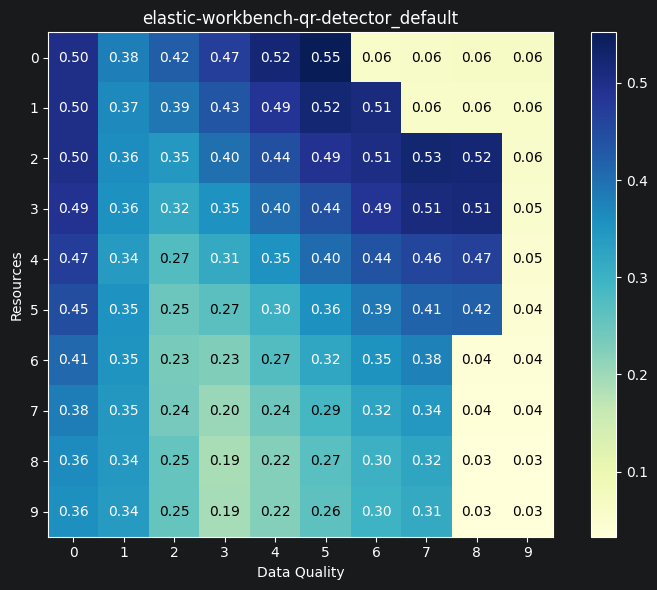

Versatile Candidate: {'coord': array([0.        , 0.63374925]), 'fitness': np.float64(0.5519504020063173)}
Versatile Candidate: {'coord': array([0.30292483, 0.8864992 ]), 'fitness': np.float64(0.525108843228255)}
Versatile Candidate: {'coord': array([0.17328904, 0.        ]), 'fitness': np.float64(0.4980584492023189)}
Versatile Candidate: {'coord': array([0.22911845, 0.66113286]), 'fitness': np.float64(0.4905821684429662)}
Versatile Candidate: {'coord': array([0.45080186, 0.        ]), 'fitness': np.float64(0.4721564480766609)}
Versatile Candidate: {'coord': array([0.11461231, 0.43016201]), 'fitness': np.float64(0.4346422126251645)}
Versatile Candidate: {'coord': array([0.56450106, 0.890281  ]), 'fitness': np.float64(0.41986967526046837)}
Versatile Candidate: {'coord': array([0.66716739, 0.03862962]), 'fitness': np.float64(0.4089715906246217)}
Versatile Candidate: {'coord': array([0.44728216, 0.66376179]), 'fitness': np.float64(0.4042587018736566)}
Versatile Candidate: {'coord': array(

In [6]:
extract_pfo_for_SLOs(gp_service, slos_default, "default")

Iteration 0: Elite found in bin (np.int64(8), np.int64(4)) with fitness 0.0559
Iteration 100: Elite found in bin (np.int64(8), np.int64(5)) with fitness 0.0479
Iteration 400: Elite found in bin (np.int64(2), np.int64(1)) with fitness 0.2438
Iteration 700: Elite found in bin (np.int64(3), np.int64(8)) with fitness 0.0756
Iteration 1200: Elite found in bin (np.int64(1), np.int64(6)) with fitness 0.0778
Iteration 1600: Elite found in bin (np.int64(6), np.int64(0)) with fitness 0.9089
Iteration 2800: Elite found in bin (np.int64(5), np.int64(3)) with fitness 0.0998
Iteration 3400: Elite found in bin (np.int64(5), np.int64(8)) with fitness 0.0630


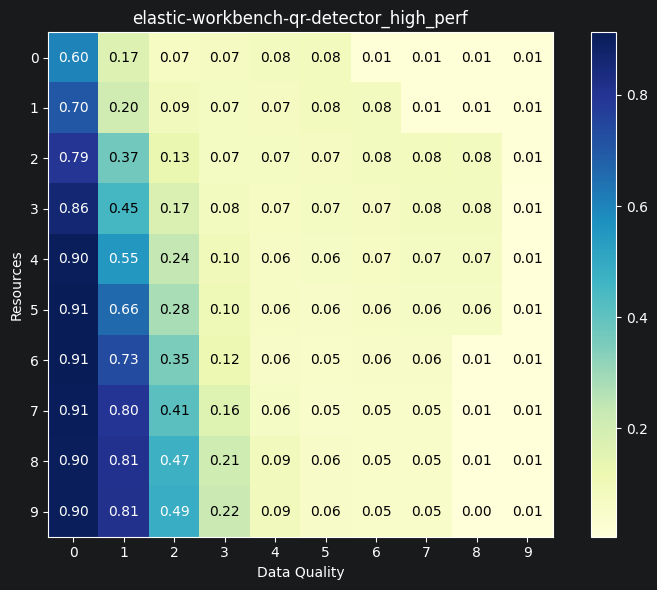

Versatile Candidate: {'coord': array([0.62561301, 0.        ]), 'fitness': np.float64(0.9125270311014491)}
Versatile Candidate: {'coord': array([0.90343261, 0.04235745]), 'fitness': np.float64(0.90353890896116)}
Versatile Candidate: {'coord': array([0.33330281, 0.        ]), 'fitness': np.float64(0.7934140156778013)}
Versatile Candidate: {'coord': array([0.10637657, 0.        ]), 'fitness': np.float64(0.6025453104479138)}
Versatile Candidate: {'coord': array([1.        , 0.22514669]), 'fitness': np.float64(0.4870982596145099)}
Versatile Candidate: {'coord': array([0.74331504, 0.22339421]), 'fitness': np.float64(0.35097359144189505)}
Versatile Candidate: {'coord': array([0.5403906 , 0.22476574]), 'fitness': np.float64(0.23736981404601623)}
Versatile Candidate: {'coord': array([0.31724573, 0.22392726]), 'fitness': np.float64(0.12796802128728252)}
Versatile Candidate: {'coord': array([0.99451045, 0.45345492]), 'fitness': np.float64(0.08917958565399342)}
Versatile Candidate: {'coord': arra

In [7]:
extract_pfo_for_SLOs(gp_service, slos_high_perf, "high_perf")

Iteration 0: Elite found in bin (np.int64(4), np.int64(2)) with fitness 0.3945


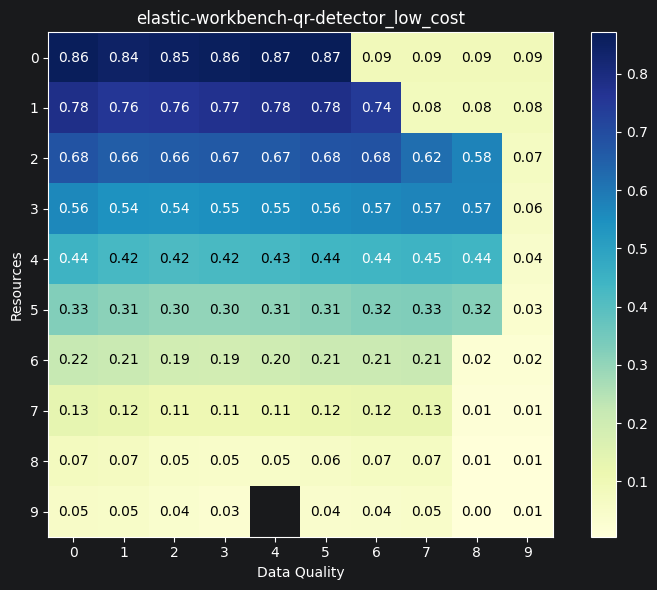

Versatile Candidate: {'coord': array([0.        , 0.63409727]), 'fitness': np.float64(0.8706865695418591)}
Versatile Candidate: {'coord': array([0., 0.]), 'fitness': np.float64(0.8605471088743296)}
Versatile Candidate: {'coord': array([0.        , 0.32924605]), 'fitness': np.float64(0.850900647605862)}
Versatile Candidate: {'coord': array([0.22356514, 0.69610394]), 'fitness': np.float64(0.6836300513317173)}
Versatile Candidate: {'coord': array([0.22249932, 0.01017251]), 'fitness': np.float64(0.680277507753368)}
Versatile Candidate: {'coord': array([0.22386787, 0.42003342]), 'fitness': np.float64(0.6663361143222951)}
Versatile Candidate: {'coord': array([0.22322007, 0.21620734]), 'fitness': np.float64(0.6568463551949962)}
Versatile Candidate: {'coord': array([0.33139368, 0.89970312]), 'fitness': np.float64(0.5757022363381731)}
Versatile Candidate: {'coord': array([0.44763974, 0.        ]), 'fitness': np.float64(0.44470588597418803)}
Versatile Candidate: {'coord': array([0.4448949 , 0.67

In [8]:
extract_pfo_for_SLOs(gp_service, slos_low_cost, "low_cost")

Iteration 0: Elite found in bin (np.int64(1), np.int64(7)) with fitness 0.0654
Iteration 100: Elite found in bin (np.int64(6), np.int64(0)) with fitness 0.3318
Iteration 400: Elite found in bin (np.int64(7), np.int64(8)) with fitness 0.0653
Iteration 600: Elite found in bin (np.int64(3), np.int64(1)) with fitness 0.2229
Iteration 3400: Elite found in bin (np.int64(1), np.int64(1)) with fitness 0.1918
Iteration 4500: Elite found in bin (np.int64(4), np.int64(3)) with fitness 0.3478


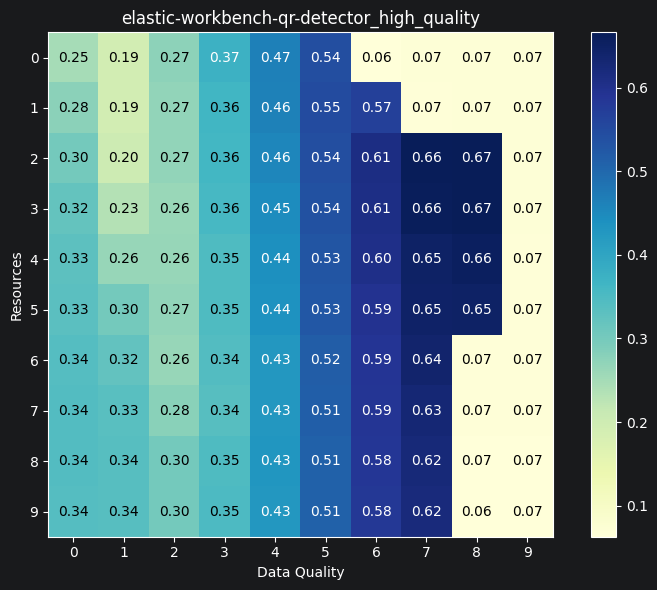

Versatile Candidate: {'coord': array([0.34423596, 0.90866456]), 'fitness': np.float64(0.6660752599632179)}
Versatile Candidate: {'coord': array([0.56095179, 0.89547698]), 'fitness': np.float64(0.6490780260129966)}
Versatile Candidate: {'coord': array([0.78776978, 0.87019134]), 'fitness': np.float64(0.6297047630014461)}
Versatile Candidate: {'coord': array([1.       , 0.8538686]), 'fitness': np.float64(0.6193665765755556)}
Versatile Candidate: {'coord': array([0.22209598, 0.69902372]), 'fitness': np.float64(0.5690184569703773)}
Versatile Candidate: {'coord': array([0.47786023, 0.66613674]), 'fitness': np.float64(0.5307260984167899)}
Versatile Candidate: {'coord': array([0.74790744, 0.66536769]), 'fitness': np.float64(0.5162712181873913)}
Versatile Candidate: {'coord': array([0.07246532, 0.55527077]), 'fitness': np.float64(0.4655986867397185)}
Versatile Candidate: {'coord': array([0.97652944, 0.55526458]), 'fitness': np.float64(0.4296673705709228)}
Versatile Candidate: {'coord': array([0

In [9]:
extract_pfo_for_SLOs(gp_service, slos_high_quality, "high_quality")